<a href="https://colab.research.google.com/github/bitwise-arnesh/ml-lab-experiments/blob/main/Experiment-2/2(ii)-Fuel-Consumption-Polynomial-Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Lab Experiment 2(ii)

## Fuel Consumption - Polynomial Regression

### Objective

Split the given Fuel Consumption dataset into training and testing data in a 70:30 ratio. Perform Polynomial Regression using degrees 2, 3, and 5. Evaluate the models using Mean Squared Error (MSE) and determine which polynomial degree gives the best performance.

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
# Load the Fuel Consumption dataset
df = pd.read_csv("fuel_consumption_dataset.csv")

# Display the column names
print(df.columns)

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')


In [ ]:
# Select the input feature
X = df[["ENGINESIZE"]]

# Select the target variable
y = df["CO2EMISSIONS"]

# Split the dataset into 70% training and 30% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Display the number of samples
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 746
Testing samples: 321


In [ ]:
# Store the MSE results for each polynomial degree
results = {}

# Test polynomial degrees from 1 to 7
for degree in range(1, 9):

    # Convert the input feature into polynomial features
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create the Linear Regression model
    model = LinearRegression()

    # Train the model using the training data
    model.fit(X_train_poly, y_train)

    # Predict training and testing values
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Store the testing MSE
    results[degree] = test_mse

    # Display the results
    print("Polynomial Degree:", degree)
    print("Training MSE:", train_mse)
    print("Testing MSE:", test_mse)
    print()

Polynomial Degree: 1
Training MSE: 965.0040344548032
Testing MSE: 904.109398261533

Polynomial Degree: 2
Training MSE: 960.4759110438947
Testing MSE: 884.6746326637154

Polynomial Degree: 3
Training MSE: 957.1581013028144
Testing MSE: 879.272398652148

Polynomial Degree: 4
Training MSE: 956.0535019890209
Testing MSE: 880.9577757653327

Polynomial Degree: 5
Training MSE: 952.0962684783537
Testing MSE: 882.038369365134

Polynomial Degree: 6
Training MSE: 945.8454016330161
Testing MSE: 883.5688154388606

Polynomial Degree: 7
Training MSE: 936.4247372654842
Testing MSE: 870.7703189420448

Polynomial Degree: 8
Training MSE: 934.6359538896236
Testing MSE: 867.5862071699361



In [ ]:
# Find the polynomial degree with the lowest testing MSE
best_degree = min(results, key=results.get)

print("Best Polynomial Degree:", best_degree)
print("Lowest Testing MSE:", results[best_degree])

Best Polynomial Degree: 8
Lowest Testing MSE: 867.5862071699361


In [ ]:
# Create polynomial features using the best degree
poly = PolynomialFeatures(degree=best_degree)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train the Linear Regression model
best_model = LinearRegression()

best_model.fit(X_train_poly, y_train)

# Make predictions
y_train_pred = best_model.predict(X_train_poly)
y_test_pred = best_model.predict(X_test_poly)

# Calculate final MSE values
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Best Degree:", best_degree)
print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

Best Degree: 8
Training MSE: 934.6359538896236
Testing MSE: 867.5862071699361


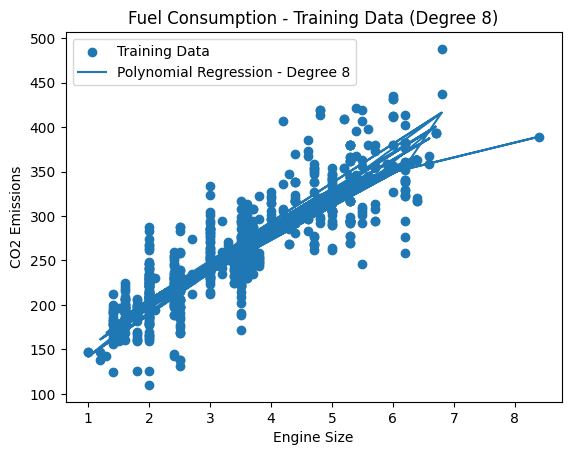

In [ ]:
# Plot the actual training data
plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

# Plot the polynomial regression curve
plt.plot(
    X_train,
    y_train_pred,
    label=f"Polynomial Regression - Degree {best_degree}"
)

plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title(f"Fuel Consumption - Training Data (Degree {best_degree})")
plt.legend()
plt.show()

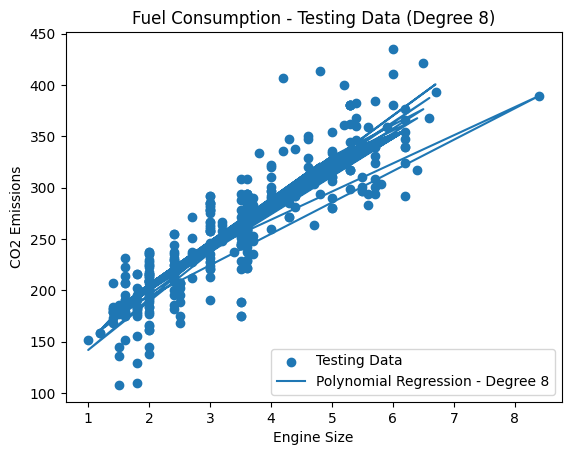

In [ ]:
# Plot the actual testing data
plt.scatter(
    X_test,
    y_test,
    label="Testing Data"
)

# Plot the polynomial regression curve
plt.plot(
    X_test,
    y_test_pred,
    label=f"Polynomial Regression - Degree {best_degree}"
)

plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title(f"Fuel Consumption - Testing Data (Degree {best_degree})")
plt.legend()
plt.show()

In [ ]:
# Display the testing MSE for each polynomial degree
print("Testing MSE Comparison")

for degree, mse in results.items():
    print(f"Degree {degree}: {mse}")

Testing MSE Comparison
Degree 1: 904.109398261533
Degree 2: 884.6746326637154
Degree 3: 879.272398652148
Degree 4: 880.9577757653327
Degree 5: 882.038369365134
Degree 6: 883.5688154388606
Degree 7: 870.7703189420448
Degree 8: 867.5862071699361


## Result

Polynomial Regression models of degrees 2, 3, and 5 were trained using the 70% training data and evaluated using the 30% testing data.

The models were compared using Mean Squared Error (MSE). The polynomial degree with the lowest testing MSE was selected as the best-performing model.

## Conclusion

The Fuel Consumption dataset was successfully divided into training and testing data in a 70:30 ratio. Polynomial Regression was performed using degrees 2, 3, and 5. The model with the lowest testing MSE was considered the best fit for the dataset.